# Frobenius Group of Order 21: Standard GD Training (Fixed Scale)

Training with **standard gradient descent** (no spherical projection) with scale parameters fixed.

**Key difference from spherical training:** Weights do NOT stay on the unit sphere. Their norms can grow or shrink during training.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter

from src.tasks import Frobenius21Multiplication
from src.basis import Frobenius21Basis
from src.model import WideNetworkScaleSphere
from src.utils import cross_entropy_high_precision, accuracy
from src.frobenius_analysis import d_sim, extract_irrep_matrices, compute_irrep_energy, compute_grouped_energy, compute_sv_ratio
from src.plotting import (setup_plot_style, make_blue_white_red_cmap,
                          get_frobenius_display_info, scale_by_sqrt_d,
                          plot_dft_bars, plot_dft_heatmap, FROBENIUS21_IRREP_LATEX)

setup_plot_style()
blue_white_red = make_blue_white_red_cmap()

## 1. Configuration

In [2]:
WIDTH = 512
ACT_TYPE = 'Quad'
INIT_SCALE = 1.0
SHARE_EMBED = False

LR = 1e-3
NUM_EPOCHS = 5000
PRINT_EVERY = 500
TRACK_EVERY = 10

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cpu')
vocab_size = 21

print(f"Frobenius Group: G = C_7 ⋊ C_3, |G| = {vocab_size}")
print(f"Model: width={WIDTH}, act={ACT_TYPE}, share_embed={SHARE_EMBED}")

Frobenius Group: G = C_7 ⋊ C_3, |G| = 21
Model: width=512, act=Quad, share_embed=False


## 2. Initialize Task, Basis, and Model

In [3]:
# Create task and basis
task = Frobenius21Multiplication()
basis = Frobenius21Basis()

print(f"Task: {task}")
print(f"Basis: {basis}")
print(f"\nIrreducible representations (label -> dimension):")
for label, dim in basis.irrep_dimensions.items():
    print(f"  {label}: dim = {dim} -> contributes {dim**2} basis functions")
print(f"\nTotal basis functions: {sum(d**2 for d in basis.irrep_dimensions.values())} = {vocab_size}")
print(f"\nConjugate pairs:")
print(f"  - omega & omega_conj (both 1D)")
print(f"  - rho_3 & rho_3_conj (both 3D)")

Task: Frobenius21Multiplication(vocab_size=21)
Basis: Frobenius21Basis(size=21, irreps={trivial:1, omega:1, omega_conj:1, rho_3:3, rho_3_conj:3})

Irreducible representations (label -> dimension):
  trivial: dim = 1 -> contributes 1 basis functions
  omega: dim = 1 -> contributes 1 basis functions
  omega_conj: dim = 1 -> contributes 1 basis functions
  rho_3: dim = 3 -> contributes 9 basis functions
  rho_3_conj: dim = 3 -> contributes 9 basis functions

Total basis functions: 21 = 21

Conjugate pairs:
  - omega & omega_conj (both 1D)
  - rho_3 & rho_3_conj (both 3D)


In [4]:
# Generate data
data, labels = task.generate_all_data(device)

# Create model
model = WideNetworkScaleSphere(
    d_vocab=vocab_size,
    width=WIDTH,
    act_type=ACT_TYPE,
    init_scale=INIT_SCALE,
    share_embed=SHARE_EMBED,
).to(device)

print(f"\nModel architecture:")
print(f"  W_in:  {model.W_in.shape}  <- (width, 2*vocab_size) for unshared")
print(f"  W_out: {model.W_out.shape}")
print(f"  scale_in:  {model.scale_in.item():.4f}")
print(f"  scale_out: {model.scale_out.item():.4f}")
print(f"\nDataset: {len(data)} samples")


Model architecture:
  W_in:  torch.Size([512, 42])  <- (width, 2*vocab_size) for unshared
  W_out: torch.Size([21, 512])
  scale_in:  1.0000
  scale_out: 1.0000

Dataset: 441 samples


## 3. Run Training (Standard GD, Fixed Scale)

Standard gradient descent **without** projection to tangent space or normalization.
Weights are free to leave the unit sphere.

In [5]:
W_in_init = model.W_in.detach().cpu().clone()
W_out_init = model.W_out.detach().cpu().clone()

model.scale_in.requires_grad = False
model.scale_out.requires_grad = False

optimizer = optim.Adam([model.W_in, model.W_out], lr=LR)

losses = []
accuracies = []

# Track weight norms (unique to standard GD — weights leave the sphere)
norm_history_theta1 = []
norm_history_theta2 = []
norm_history_xi = []

def compute_all_metrics_at_epoch(model_obj, basis_obj, vocab_sz):
    """Alignment, energy, and rank-1 metrics on raw (unnormalized) weights."""
    W_in = model_obj.W_in.detach().cpu()
    W_out = model_obj.W_out.detach().cpu()
    W_in_pos1_dft = basis_obj.transform_paper(W_in[:, :vocab_sz]).numpy()
    W_in_pos2_dft = basis_obj.transform_paper(W_in[:, vocab_sz:]).numpy()
    W_out_dft     = basis_obj.transform_paper(W_out.T).numpy()

    W1_mats   = extract_irrep_matrices(W_in_pos1_dft, basis_obj.irrep_labels, basis_obj.irrep_dimensions)
    W2_mats   = extract_irrep_matrices(W_in_pos2_dft, basis_obj.irrep_labels, basis_obj.irrep_dimensions)
    Wout_mats = extract_irrep_matrices(W_out_dft,     basis_obj.irrep_labels, basis_obj.irrep_dimensions)

    ge1, glabels = compute_grouped_energy(compute_irrep_energy(np.abs(W_in_pos1_dft), basis_obj.irrep_labels, basis_obj.irrep_dimensions), basis_obj.irrep_labels)
    ge2, _       = compute_grouped_energy(compute_irrep_energy(np.abs(W_in_pos2_dft), basis_obj.irrep_labels, basis_obj.irrep_dimensions), basis_obj.irrep_labels)
    geo, _       = compute_grouped_energy(compute_irrep_energy(np.abs(W_out_dft),     basis_obj.irrep_labels, basis_obj.irrep_dimensions), basis_obj.irrep_labels)

    n = W_in.shape[0]
    align = {lbl: {'cond1': [], 'cond2': [], 'cond3': []} for lbl in basis_obj.irrep_labels if lbl != 'trivial'}
    rank1 = {lbl: {'theta1': [], 'theta2': [], 'xi': []} for lbl in basis_obj.irrep_labels if basis_obj.irrep_dimensions[lbl] > 1}

    for m in range(n):
        for lbl in basis_obj.irrep_labels:
            if lbl == 'trivial':
                continue
            W1, W2, Wo = W1_mats[lbl][m], W2_mats[lbl][m], Wout_mats[lbl][m]
            align[lbl]['cond1'].append(d_sim(W2 @ W1, Wo))
            align[lbl]['cond2'].append(d_sim(W2.conj().T @ Wo, W1))
            align[lbl]['cond3'].append(d_sim(Wo @ W1.conj().T, W2))
            if basis_obj.irrep_dimensions[lbl] > 1:
                rank1[lbl]['theta1'].append(compute_sv_ratio(W1))
                rank1[lbl]['theta2'].append(compute_sv_ratio(W2))
                rank1[lbl]['xi'].append(compute_sv_ratio(Wo))

    return align, ge1, ge2, geo, glabels, rank1

def compute_weight_norms(model_obj, vocab_sz):
    W_in = model_obj.W_in.detach().cpu()
    W_out = model_obj.W_out.detach().cpu()
    return (W_in[:, :vocab_sz].norm(dim=1).mean().item(),
            W_in[:, vocab_sz:].norm(dim=1).mean().item(),
            W_out.norm(dim=0).mean().item())

epochs_tracked = []
alignment_history_all = {lbl: {'cond1': [], 'cond2': [], 'cond3': []} for lbl in basis.irrep_labels if lbl != 'trivial'}
grouped_energy_history_theta1 = []
grouped_energy_history_theta2 = []
grouped_energy_history_xi = []
grouped_labels_cache = None
rank1_history = {lbl: {'theta1': [], 'theta2': [], 'xi': []} for lbl in basis.irrep_labels if basis.irrep_dimensions[lbl] > 1}

print("=" * 60)
print("Standard GD Training (Scale fixed, NO spherical projection)")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    if epoch % TRACK_EVERY == 0:
        al, ge1, ge2, geo, glbls, r1 = compute_all_metrics_at_epoch(model, basis, vocab_size)
        epochs_tracked.append(epoch)
        grouped_energy_history_theta1.append(ge1)
        grouped_energy_history_theta2.append(ge2)
        grouped_energy_history_xi.append(geo)
        grouped_labels_cache = glbls
        for lbl in alignment_history_all:
            alignment_history_all[lbl]['cond1'].append(al[lbl]['cond1'])
            alignment_history_all[lbl]['cond2'].append(al[lbl]['cond2'])
            alignment_history_all[lbl]['cond3'].append(al[lbl]['cond3'])
        for lbl in rank1_history:
            rank1_history[lbl]['theta1'].append(r1[lbl]['theta1'])
            rank1_history[lbl]['theta2'].append(r1[lbl]['theta2'])
            rank1_history[lbl]['xi'].append(r1[lbl]['xi'])
        n1, n2, n3 = compute_weight_norms(model, vocab_size)
        norm_history_theta1.append(n1)
        norm_history_theta2.append(n2)
        norm_history_xi.append(n3)

    optimizer.zero_grad()
    logits = model(data)
    loss = cross_entropy_high_precision(logits, labels)
    acc  = accuracy(logits, labels)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    accuracies.append(acc)
    if epoch % PRINT_EVERY == 0:
        n1, n2, n3 = compute_weight_norms(model, vocab_size)
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6f} | Acc: {acc:.4f} | "
              f"Norms: θ1={n1:.3f}, θ2={n2:.3f}, ξ={n3:.3f}")

# Final tracking
al, ge1, ge2, geo, glbls, r1 = compute_all_metrics_at_epoch(model, basis, vocab_size)
epochs_tracked.append(NUM_EPOCHS)
grouped_energy_history_theta1.append(ge1)
grouped_energy_history_theta2.append(ge2)
grouped_energy_history_xi.append(geo)
grouped_labels_cache = glbls
for lbl in alignment_history_all:
    alignment_history_all[lbl]['cond1'].append(al[lbl]['cond1'])
    alignment_history_all[lbl]['cond2'].append(al[lbl]['cond2'])
    alignment_history_all[lbl]['cond3'].append(al[lbl]['cond3'])
for lbl in rank1_history:
    rank1_history[lbl]['theta1'].append(r1[lbl]['theta1'])
    rank1_history[lbl]['theta2'].append(r1[lbl]['theta2'])
    rank1_history[lbl]['xi'].append(r1[lbl]['xi'])
n1, n2, n3 = compute_weight_norms(model, vocab_size)
norm_history_theta1.append(n1)
norm_history_theta2.append(n2)
norm_history_xi.append(n3)

print(f"\nFinal | Loss: {losses[-1]:.6f} | Acc: {accuracies[-1]:.4f}")
print(f"Final avg norms: θ1={n1:.4f}, θ2={n2:.4f}, ξ={n3:.4f}")

Standard GD Training (Scale fixed, NO spherical projection)
Epoch     0 | Loss: 1342.638428 | Acc: 0.0340 | Norms: θ1=0.706, θ2=0.700, ξ=1.000


Epoch   500 | Loss: 1110.883301 | Acc: 1.0000 | Norms: θ1=4.147, θ2=4.135, ξ=4.410


Epoch  1000 | Loss: 193.248322 | Acc: 1.0000 | Norms: θ1=7.749, θ2=7.723, ξ=8.011


Epoch  1500 | Loss: 30.863976 | Acc: 1.0000 | Norms: θ1=9.010, θ2=8.976, ξ=9.276


Epoch  2000 | Loss: 11.260153 | Acc: 1.0000 | Norms: θ1=9.537, θ2=9.500, ξ=9.807


...

Epoch  3000 | Loss: 3.187046 | Acc: 1.0000 | Norms: θ1=10.116, θ2=10.078, ξ=10.391


Epoch  3500 | Loss: 1.977888 | Acc: 1.0000 | Norms: θ1=10.318, θ2=10.279, ξ=10.595


Epoch  4000 | Loss: 1.292662 | Acc: 1.0000 | Norms: θ1=10.491, θ2=10.452, ξ=10.770


Epoch  4500 | Loss: 0.874865 | Acc: 1.0000 | Norms: θ1=10.645, θ2=10.606, ξ=10.926



Final | Loss: 0.607336 | Acc: 1.0000
Final avg norms: θ1=10.7846, θ2=10.7460, ξ=11.0675


### 3.1 Weight Norm Evolution (Departure from Sphere)

In standard GD, weights are free to leave the unit sphere. This plot shows how the average norms evolve during training.

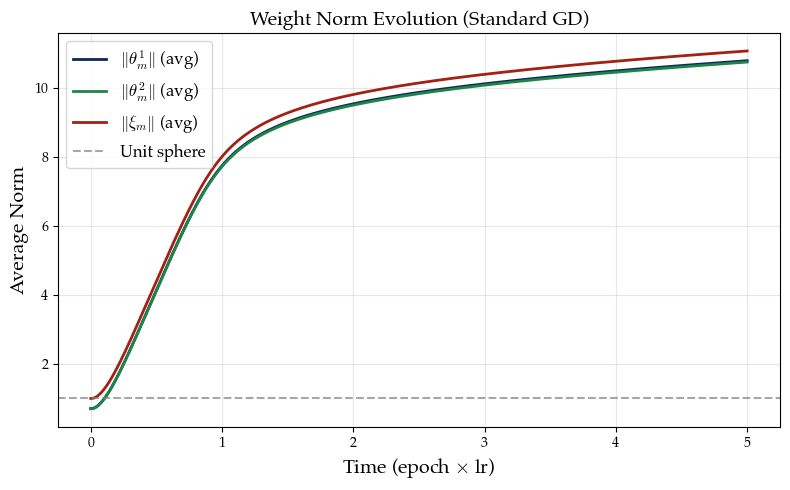


Norm change from init to final:
  θ1: 0.7060 → 10.7846 (Δ = +10.0786)
  θ2: 0.7005 → 10.7460 (Δ = +10.0455)
  ξ:  1.0000 → 11.0675 (Δ = +10.0675)


In [6]:
# Plot weight norm evolution during training
fig, ax = plt.subplots(figsize=(8, 5))

time_arr = np.array(epochs_tracked) * LR

ax.plot(time_arr, norm_history_theta1, color='#0D2758', linewidth=2, label=r'$\|\theta^1_m\|$ (avg)')
ax.plot(time_arr, norm_history_theta2, color='#1E8449', linewidth=2, label=r'$\|\theta^2_m\|$ (avg)')
ax.plot(time_arr, norm_history_xi, color='#A32015', linewidth=2, label=r'$\|\xi_m\|$ (avg)')

ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Unit sphere')
ax.set_xlabel(r'Time (epoch $\times$ lr)', fontsize=14)
ax.set_ylabel('Average Norm', fontsize=14)
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3)
ax.set_title('Weight Norm Evolution (Standard GD)', fontsize=14)

plt.tight_layout()
plt.show()

print(f"\nNorm change from init to final:")
print(f"  θ1: {norm_history_theta1[0]:.4f} → {norm_history_theta1[-1]:.4f} (Δ = {norm_history_theta1[-1] - norm_history_theta1[0]:+.4f})")
print(f"  θ2: {norm_history_theta2[0]:.4f} → {norm_history_theta2[-1]:.4f} (Δ = {norm_history_theta2[-1] - norm_history_theta2[0]:+.4f})")
print(f"  ξ:  {norm_history_xi[0]:.4f} → {norm_history_xi[-1]:.4f} (Δ = {norm_history_xi[-1] - norm_history_xi[0]:+.4f})")


## 4. DFT Analysis (Unnormalized Weights)

**Note:** Unlike spherical training, we do NOT normalize weights before DFT.
This shows the true Fourier structure including the effect of weight magnitude changes.

In [7]:
W_in  = model.W_in.detach().cpu()
W_out = model.W_out.detach().cpu()
M = WIDTH
G_ORDER = 21

W_in_pos1      = W_in[:, :vocab_size]
W_in_pos2      = W_in[:, vocab_size:]
W_in_init_pos1 = W_in_init[:, :vocab_size]
W_in_init_pos2 = W_in_init[:, vocab_size:]

# NO normalization — use raw weights (standard GD)
W_in_pos1_dft      = basis.transform_paper(W_in_pos1)
W_in_pos2_dft      = basis.transform_paper(W_in_pos2)
W_out_dft          = basis.transform_paper(W_out.T)
W_in_init_pos1_dft = basis.transform_paper(W_in_init_pos1)
W_in_init_pos2_dft = basis.transform_paper(W_in_init_pos2)
W_out_init_dft     = basis.transform_paper(W_out_init.T)

W_in_pos1_mag      = torch.abs(W_in_pos1_dft).numpy()
W_in_pos2_mag      = torch.abs(W_in_pos2_dft).numpy()
W_out_mag          = torch.abs(W_out_dft).numpy()
W_in_init_pos1_mag = torch.abs(W_in_init_pos1_dft).numpy()
W_in_init_pos2_mag = torch.abs(W_in_init_pos2_dft).numpy()
W_out_init_mag     = torch.abs(W_out_init_dft).numpy()

basis_labels, irrep_centers, irrep_boundaries = get_frobenius_display_info(basis)

print(f"W_in_pos1_dft: {W_in_pos1_dft.shape},  W_out_dft: {W_out_dft.shape}")
print(f"Weight norms (trained): θ1={W_in_pos1.norm(dim=1).mean():.4f}, "
      f"θ2={W_in_pos2.norm(dim=1).mean():.4f}, ξ={W_out.norm(dim=0).mean():.4f}")

W_in_pos1_dft: torch.Size([512, 21]),  W_out_dft: torch.Size([512, 21])
Weight norms (trained): θ1=10.7846, θ2=10.7460, ξ=11.0675


### 4.1 Single Representation Phenomenon (Representation-Level View)

We compute the L²(G) energy in each irrep block using paper's Plancherel formula:
$$E_\rho^{(m)} = d_\rho \|\hat{\nu}_m[\rho]\|_F^2$$

By Plancherel: $\sum_\rho E_\rho^{(m)} = \|\nu_m\|_{L^2(G)}^2 = \frac{1}{|G|}$ for unit-norm signals.

Note: The Frobenius group has TWO pairs of conjugate irreps:
- omega & omega_conj (1D)
- rho_3 & rho_3_conj (3D)

In [8]:
energy_pos1 = compute_irrep_energy(W_in_pos1_mag, basis.irrep_labels, basis.irrep_dimensions)
energy_pos2 = compute_irrep_energy(W_in_pos2_mag, basis.irrep_labels, basis.irrep_dimensions)
energy_out  = compute_irrep_energy(W_out_mag,     basis.irrep_labels, basis.irrep_dimensions)

energy_pos1_grouped, grouped_labels = compute_grouped_energy(energy_pos1, basis.irrep_labels)
energy_pos2_grouped, _              = compute_grouped_energy(energy_pos2, basis.irrep_labels)
energy_out_grouped,  _              = compute_grouped_energy(energy_out,  basis.irrep_labels)

print(f"Grouped irrep labels: {grouped_labels}")
print(f"\nPer-neuron energy (first 5, position 1):")
header = f"{'Neuron':<8}" + "".join(f"{lbl:<18}" for lbl in grouped_labels) + "Sum"
print(header)
for m in range(5):
    row = f"{m:<8}" + "".join(f"{e:<18.4f}" for e in energy_pos1_grouped[m])
    print(row + f"{energy_pos1_grouped[m].sum():.4f}")

Grouped irrep labels: ['trivial', 'omega+omega_conj', 'rho_3+rho_3_conj']

Per-neuron energy (first 5, position 1):
Neuron  trivial           omega+omega_conj  rho_3+rho_3_conj  Sum
0       0.3967            4.2653            0.0379            4.6999
1       0.4765            4.6757            0.1085            5.2608
2       0.0511            0.1269            6.1752            6.3532
3       0.0196            0.2789            5.0525            5.3510
4       0.0082            0.1363            6.3872            6.5317


### 4.2 Fine-Grained View: Individual Basis Functions

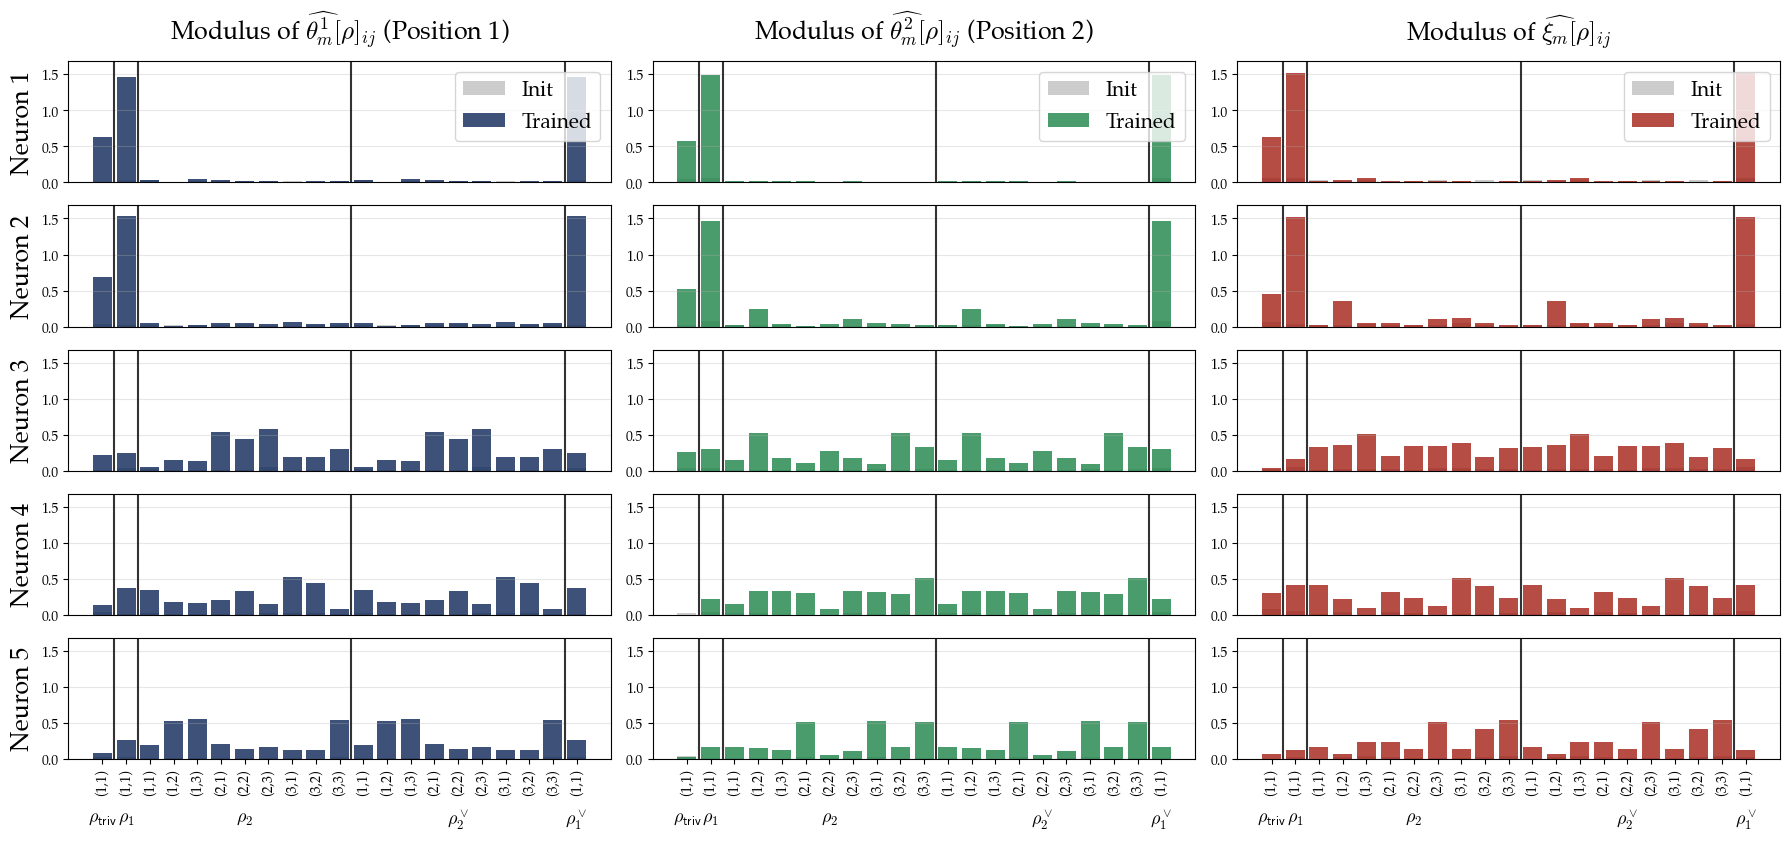

In [9]:
vline_positions = [start - 0.5 for start, _ in irrep_boundaries if start > 0]
bottom_annotations = [(center, FROBENIUS21_IRREP_LATEX[lbl])
                      for center, lbl in zip(irrep_centers, basis.irrep_labels)]

# Adaptive ylim based on max value across shown neurons
y_max = max(W_in_pos1_mag[:5].max(), W_in_pos2_mag[:5].max(), W_out_mag[:5].max(),
            W_in_init_pos1_mag[:5].max(), W_in_init_pos2_mag[:5].max(), W_out_init_mag[:5].max()) * 1.1

fig = plot_dft_bars(
    [W_in_init_pos1_mag, W_in_init_pos2_mag, W_out_init_mag],
    [W_in_pos1_mag, W_in_pos2_mag, W_out_mag],
    ['#0D2758', '#1E8449', '#A32015'],
    [r'Modulus of $\widehat{\theta_m^1}[\rho]_{ij}$ (Position 1)',
     r'Modulus of $\widehat{\theta_m^2}[\rho]_{ij}$ (Position 2)',
     r'Modulus of $\widehat{\xi_m}[\rho]_{ij}$'],
    basis_labels,
    vline_positions=vline_positions,
    bottom_annotations=bottom_annotations,
    num_neurons=5, ylim=y_max,
)
plt.show()

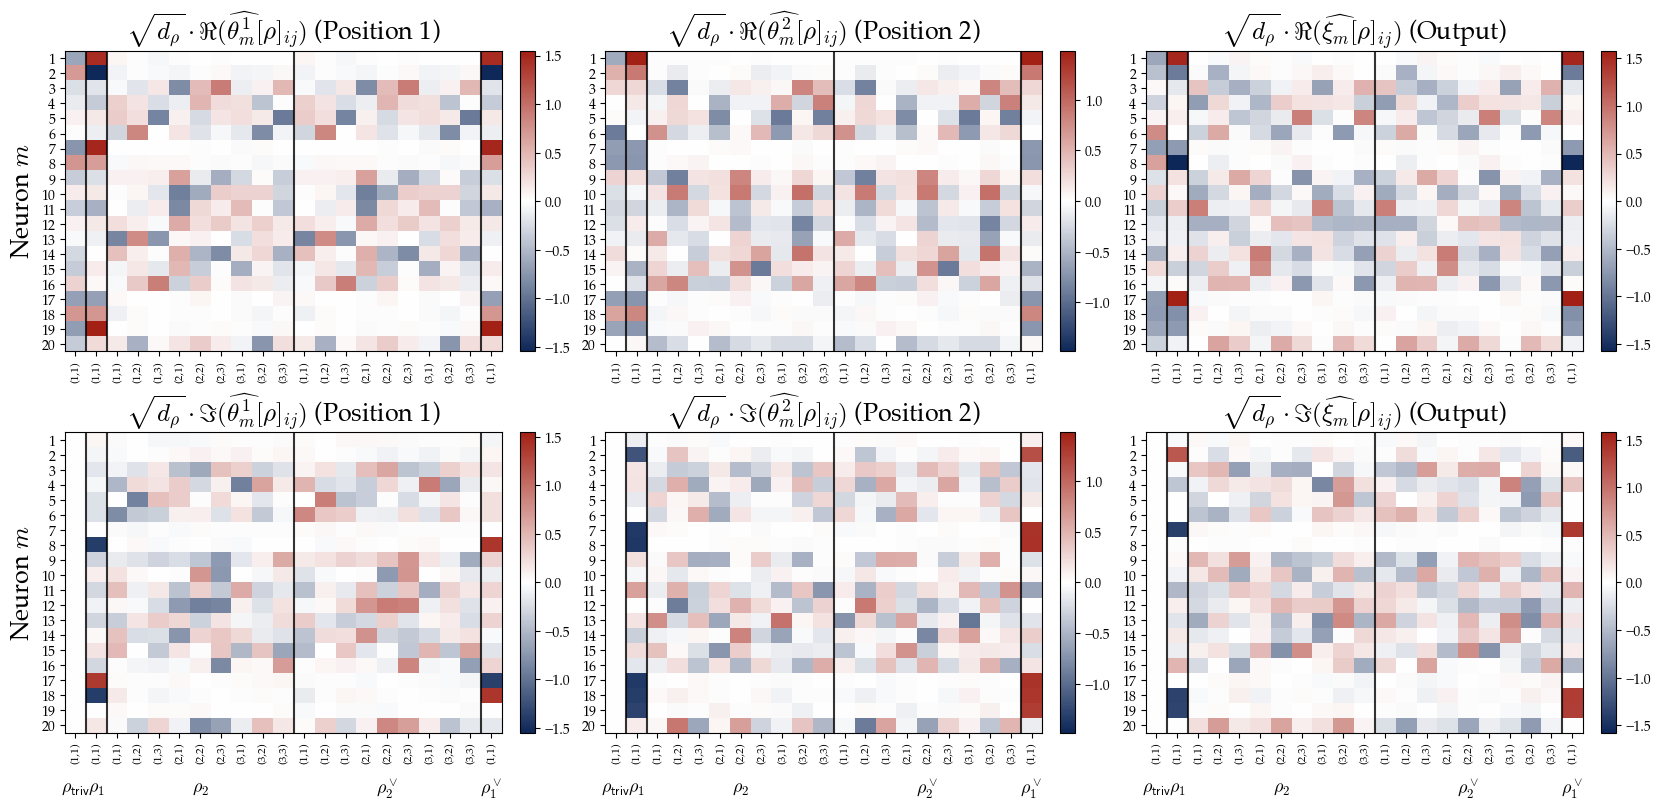

In [10]:
num_components = 20

W1s = scale_by_sqrt_d(W_in_pos1_dft[:num_components], basis)
W2s = scale_by_sqrt_d(W_in_pos2_dft[:num_components], basis)
Wos = scale_by_sqrt_d(W_out_dft[:num_components], basis)

fig = plot_dft_heatmap(
    [W1s, W2s, Wos],
    [r'$\sqrt{d_\rho}\cdot\Re(\widehat{\theta_m^1}[\rho]_{ij})$ (Position 1)',
     r'$\sqrt{d_\rho}\cdot\Re(\widehat{\theta_m^2}[\rho]_{ij})$ (Position 2)',
     r'$\sqrt{d_\rho}\cdot\Re(\widehat{\xi_m}[\rho]_{ij})$ (Output)'],
    [r'$\sqrt{d_\rho}\cdot\Im(\widehat{\theta_m^1}[\rho]_{ij})$ (Position 1)',
     r'$\sqrt{d_\rho}\cdot\Im(\widehat{\theta_m^2}[\rho]_{ij})$ (Position 2)',
     r'$\sqrt{d_\rho}\cdot\Im(\widehat{\xi_m}[\rho]_{ij})$ (Output)'],
    basis_labels,
    vline_positions=vline_positions,
    bottom_annotations=bottom_annotations,
    cmap=blue_white_red,
)
plt.show()

## 5. Fourier Coefficient Structure

We check if $\hat{\theta}^2_m[\rho] \cdot \hat{\theta}^1_m[\rho] \propto \hat{\xi}_m[\rho]$

**Notation:** All DFT coefficients use paper's L²(G) convention:
$$\hat{\nu}[\rho] = \frac{1}{|G|} \sum_{g \in G} \nu(g) \rho(g^{-1})$$
These are converted from the code's Euclidean coefficients via $\hat{\nu}[\rho] = C[\rho] / \sqrt{|G| \cdot d_\rho}$.

In [11]:
W_in_pos1_matrices = extract_irrep_matrices(W_in_pos1_dft.numpy(), basis.irrep_labels, basis.irrep_dimensions)
W_in_pos2_matrices = extract_irrep_matrices(W_in_pos2_dft.numpy(), basis.irrep_labels, basis.irrep_dimensions)
W_out_matrices     = extract_irrep_matrices(W_out_dft.numpy(),     basis.irrep_labels, basis.irrep_dimensions)

for label, mat in W_in_pos1_matrices.items():
    d = basis.irrep_dimensions[label]
    print(f"  {label}: shape = {mat.shape}  ({WIDTH} neurons × {d} × {d})")

  trivial: shape = (512, 1, 1)  (512 neurons × 1 × 1)
  omega: shape = (512, 1, 1)  (512 neurons × 1 × 1)
  rho_3: shape = (512, 3, 3)  (512 neurons × 3 × 3)
  rho_3_conj: shape = (512, 3, 3)  (512 neurons × 3 × 3)
  omega_conj: shape = (512, 1, 1)  (512 neurons × 1 × 1)


/var/folders/5n/bjfmhydx1099fm08r1bdw9br0000gn/T/ipykernel_67588/3505994959.py:110: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_plot = cm.get_cmap("plasma")


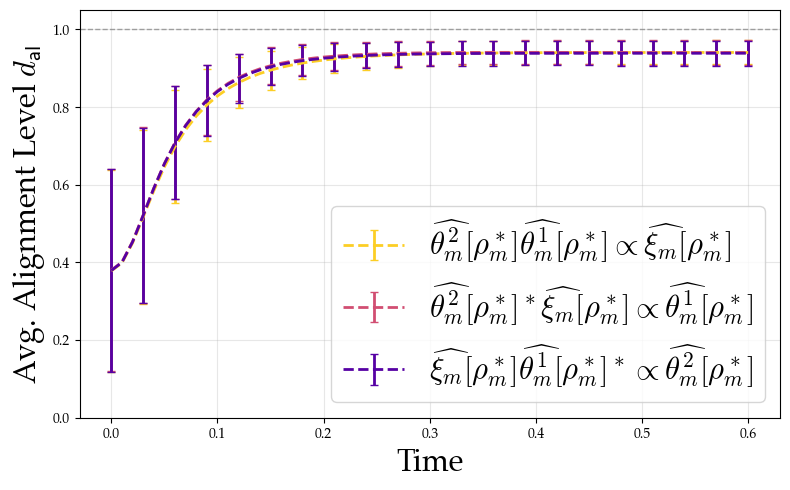

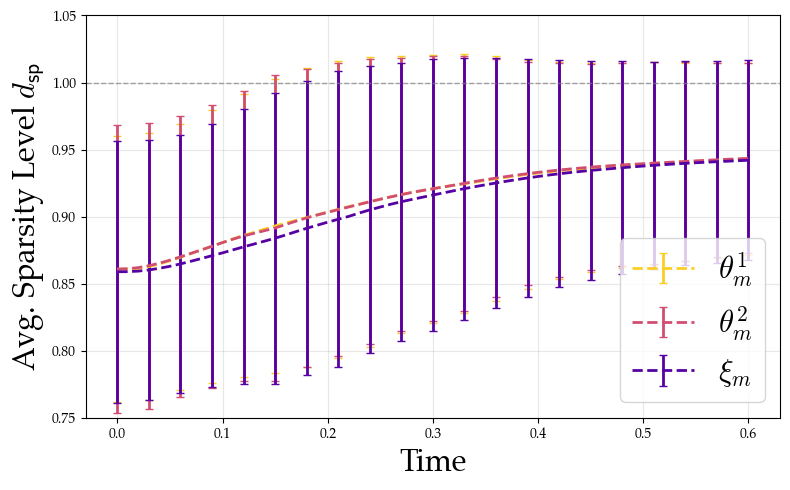

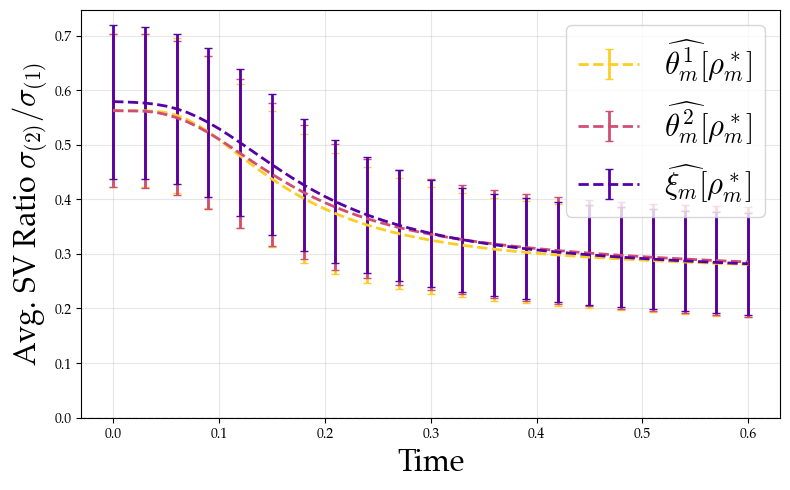


Final metrics at epoch 600:

Alignment (mean +/- std):
  Cond 1: 0.9406 +/- 0.0310
  Cond 2: 0.9404 +/- 0.0317
  Cond 3: 0.9386 +/- 0.0322

Max energy proportion (sparsity):
  theta1: 0.9430 +/- 0.0714
  theta2: 0.9434 +/- 0.0708
  xi:     0.9420 +/- 0.0745

Rank-1 ratio sigma2/sigma1 (d > 1 irreps):
  theta1: 0.280445 +/- 0.096998
  theta2: 0.285122 +/- 0.100237
  xi:     0.281804 +/- 0.092969

Non-trivial neurons: 512
Neurons with d > 1 irreps: 455


In [12]:
# Plot all metrics throughout training
# Uses alignment_history_all, grouped_energy_history_theta1/theta2/xi, rank1_history from cell-8

# === CONFIGURABLE: Set end epoch for plotting (None = plot all) ===
END_EPOCH = 600  # e.g., 200, 500, or None for full training

# Convert to arrays
epochs_arr = np.array(epochs_tracked)
time_arr = epochs_arr * LR  # x-axis: epoch * lr
n_epochs = len(epochs_tracked)
n_neurons = grouped_energy_history_theta1[-1].shape[0]

# Filter to end epoch if specified
if END_EPOCH is not None:
    epoch_mask = epochs_arr <= END_EPOCH
    epochs_arr = epochs_arr[epoch_mask]
    time_arr = time_arr[epoch_mask]
    n_epochs = len(epochs_arr)

# Determine final dominant irrep (non-grouped) for alignment and rank-1 plots
# Use theta1 energy for this
final_energy_theta1 = grouped_energy_history_theta1[-1]
final_dominant_irreps = []
for m in range(n_neurons):
    dom_idx = np.argmax(final_energy_theta1[m])
    final_dominant_irreps.append(grouped_labels_cache[dom_idx])

# ============ COMPUTE ALIGNMENT METRICS ============
cond1_per_epoch, cond2_per_epoch, cond3_per_epoch = [], [], []
for t in range(n_epochs):
    c1_vals, c2_vals, c3_vals = [], [], []
    for m in range(n_neurons):
        dom_irrep = final_dominant_irreps[m]
        if dom_irrep == "trivial" or "+" in dom_irrep:
            # For grouped labels, use first irrep
            if "+" in dom_irrep:
                dom_irrep = dom_irrep.split("+")[0]
        if dom_irrep == "trivial":
            continue
        if dom_irrep not in alignment_history_all:
            continue
        c1_vals.append(alignment_history_all[dom_irrep]["cond1"][t][m])
        c2_vals.append(alignment_history_all[dom_irrep]["cond2"][t][m])
        c3_vals.append(alignment_history_all[dom_irrep]["cond3"][t][m])
    cond1_per_epoch.append(c1_vals)
    cond2_per_epoch.append(c2_vals)
    cond3_per_epoch.append(c3_vals)

cond1_mean = np.array([np.mean(c) for c in cond1_per_epoch])
cond1_std = np.array([np.std(c) for c in cond1_per_epoch])
cond2_mean = np.array([np.mean(c) for c in cond2_per_epoch])
cond2_std = np.array([np.std(c) for c in cond2_per_epoch])
cond3_mean = np.array([np.mean(c) for c in cond3_per_epoch])
cond3_std = np.array([np.std(c) for c in cond3_per_epoch])

# ============ COMPUTE ENERGY PROPORTION (max at each step) for theta1, theta2, xi separately ============
def compute_max_energy_prop(grouped_energy_history, n_epochs, n_neurons):
    props_per_epoch = []
    for t in range(n_epochs):
        props = []
        for m in range(n_neurons):
            total_energy = np.sum(grouped_energy_history[t][m])
            if total_energy > 1e-10:
                max_prop = np.max(grouped_energy_history[t][m]) / total_energy
                props.append(max_prop)
            else:
                props.append(0.0)
        props_per_epoch.append(props)
    return props_per_epoch

energy_prop_theta1 = compute_max_energy_prop(grouped_energy_history_theta1, n_epochs, n_neurons)
energy_prop_theta2 = compute_max_energy_prop(grouped_energy_history_theta2, n_epochs, n_neurons)
energy_prop_xi = compute_max_energy_prop(grouped_energy_history_xi, n_epochs, n_neurons)

theta1_energy_mean = np.array([np.mean(p) for p in energy_prop_theta1])
theta1_energy_std = np.array([np.std(p) for p in energy_prop_theta1])
theta2_energy_mean = np.array([np.mean(p) for p in energy_prop_theta2])
theta2_energy_std = np.array([np.std(p) for p in energy_prop_theta2])
xi_energy_mean = np.array([np.mean(p) for p in energy_prop_xi])
xi_energy_std = np.array([np.std(p) for p in energy_prop_xi])

# ============ COMPUTE RANK-1 RATIO ============
theta1_sv_per_epoch, theta2_sv_per_epoch, xi_sv_per_epoch = [], [], []
for t in range(n_epochs):
    t1_vals, t2_vals, xi_vals = [], [], []
    for m in range(n_neurons):
        dom_irrep = final_dominant_irreps[m]
        if "+" in dom_irrep:
            dom_irrep = dom_irrep.split("+")[0]
        if dom_irrep == "trivial":
            continue
        if dom_irrep not in rank1_history:
            continue
        t1_vals.append(rank1_history[dom_irrep]["theta1"][t][m])
        t2_vals.append(rank1_history[dom_irrep]["theta2"][t][m])
        xi_vals.append(rank1_history[dom_irrep]["xi"][t][m])
    theta1_sv_per_epoch.append(t1_vals)
    theta2_sv_per_epoch.append(t2_vals)
    xi_sv_per_epoch.append(xi_vals)

theta1_sv_mean = np.array([np.mean(v) for v in theta1_sv_per_epoch])
theta1_sv_std = np.array([np.std(v) for v in theta1_sv_per_epoch])
theta2_sv_mean = np.array([np.mean(v) for v in theta2_sv_per_epoch])
theta2_sv_std = np.array([np.std(v) for v in theta2_sv_per_epoch])
xi_sv_mean = np.array([np.mean(v) for v in xi_sv_per_epoch])
xi_sv_std = np.array([np.std(v) for v in xi_sv_per_epoch])

# ============ SHARED COLOR SETUP (plasma colormap, 3 lines) ============
import matplotlib.cm as cm
cmap_plot = cm.get_cmap("plasma")
plot_colors = [cmap_plot(0.90 - 0.375 * i) for i in range(3)]  # purple -> teal -> yellow
err_every = max(1, len(time_arr) // 20)  # ~20 error bars across the x-axis

# ============ PLOT 1: Alignment metrics (separate figure) ============
fig1, ax = plt.subplots(figsize=(8, 5))
labels_align = [
    r"$\widehat{\theta^2_m}[\rho_m^*]\widehat{\theta^1_m}[\rho_m^*]\propto\widehat{\xi_m}[\rho_m^*]$",
    r"$\widehat{\theta^2_m}[\rho_m^*]^*\widehat{\xi_m}[\rho_m^*]\propto\widehat{\theta^1_m}[\rho_m^*]$",
    r"$\widehat{\xi_m}[\rho_m^*]\widehat{\theta^1_m}[\rho_m^*]^*\propto\widehat{\theta^2_m}[\rho_m^*]$"
]
for i, (mean, std) in enumerate([(cond1_mean, cond1_std), (cond2_mean, cond2_std), (cond3_mean, cond3_std)]):
    ax.errorbar(time_arr, mean, yerr=std, color=plot_colors[i], linewidth=2,
                linestyle="--", capsize=3, capthick=1, errorevery=err_every,
                label=labels_align[i])
ax.set_xlabel(r"Time", fontsize=22)
ax.set_ylabel(r"Avg. Alignment Level $d_{\sf al}$", fontsize=22)
ax.set_ylim(0, 1.05)
ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.legend(fontsize=22, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============ PLOT 2: Energy proportion (3 lines for theta1, theta2, xi) ============
fig2, ax = plt.subplots(figsize=(8, 5))
labels_energy = [r"$\theta^1_m$", r"$\theta^2_m$", r"$\xi_m$"]
for i, (mean, std) in enumerate([
    (theta1_energy_mean, theta1_energy_std),
    (theta2_energy_mean, theta2_energy_std),
    (xi_energy_mean, xi_energy_std)
]):
    ax.errorbar(time_arr, mean, yerr=std, color=plot_colors[i], linewidth=2,
                linestyle="--", capsize=3, capthick=1, errorevery=err_every,
                label=labels_energy[i])
ax.set_xlabel(r"Time", fontsize=22)
ax.set_ylabel(r"Avg. Sparsity Level $d_{\sf sp}$", fontsize=22)
ax.set_ylim(0.75, 1.05)
ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.legend(fontsize=22, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============ PLOT 3: Rank-1 ratio (separate figure) ============
fig3, ax = plt.subplots(figsize=(8, 5))
labels_sv = [r"$\widehat{\theta^1_m}[\rho_m^*]$", r"$\widehat{\theta^2_m}[\rho_m^*]$", r"$\widehat{\xi_m}[\rho_m^*]$"]
for i, (mean, std) in enumerate([
    (theta1_sv_mean, theta1_sv_std),
    (theta2_sv_mean, theta2_sv_std),
    (xi_sv_mean, xi_sv_std)
]):
    ax.errorbar(time_arr, mean, yerr=std, color=plot_colors[i], linewidth=2,
                linestyle="--", capsize=3, capthick=1, errorevery=err_every,
                label=labels_sv[i])
ax.set_xlabel(r"Time", fontsize=22)
ax.set_ylabel(r"Avg. SV Ratio $\sigma_{(2)} / \sigma_{(1)}$", fontsize=22)
ax.set_ylim(0, None)
ax.axhline(y=0.0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.legend(fontsize=22, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print final values
print(f"\nFinal metrics at epoch {epochs_arr[-1]}:")
print(f"\nAlignment (mean +/- std):")
print(f"  Cond 1: {cond1_mean[-1]:.4f} +/- {cond1_std[-1]:.4f}")
print(f"  Cond 2: {cond2_mean[-1]:.4f} +/- {cond2_std[-1]:.4f}")
print(f"  Cond 3: {cond3_mean[-1]:.4f} +/- {cond3_std[-1]:.4f}")
print(f"\nMax energy proportion (sparsity):")
print(f"  theta1: {theta1_energy_mean[-1]:.4f} +/- {theta1_energy_std[-1]:.4f}")
print(f"  theta2: {theta2_energy_mean[-1]:.4f} +/- {theta2_energy_std[-1]:.4f}")
print(f"  xi:     {xi_energy_mean[-1]:.4f} +/- {xi_energy_std[-1]:.4f}")
print(f"\nRank-1 ratio sigma2/sigma1 (d > 1 irreps):")
print(f"  theta1: {theta1_sv_mean[-1]:.6f} +/- {theta1_sv_std[-1]:.6f}")
print(f"  theta2: {theta2_sv_mean[-1]:.6f} +/- {theta2_sv_std[-1]:.6f}")
print(f"  xi:     {xi_sv_mean[-1]:.6f} +/- {xi_sv_std[-1]:.6f}")
print(f"\nNon-trivial neurons: {len(cond1_per_epoch[0])}")
print(f"Neurons with d > 1 irreps: {len(theta1_sv_per_epoch[0]) if theta1_sv_per_epoch else 0}")

Selected neurons and their dominant irreps:
  Neuron 1: omega (dim=1)
  Neuron 3: rho_3 (dim=3)
  Neuron 4: rho_3 (dim=3)


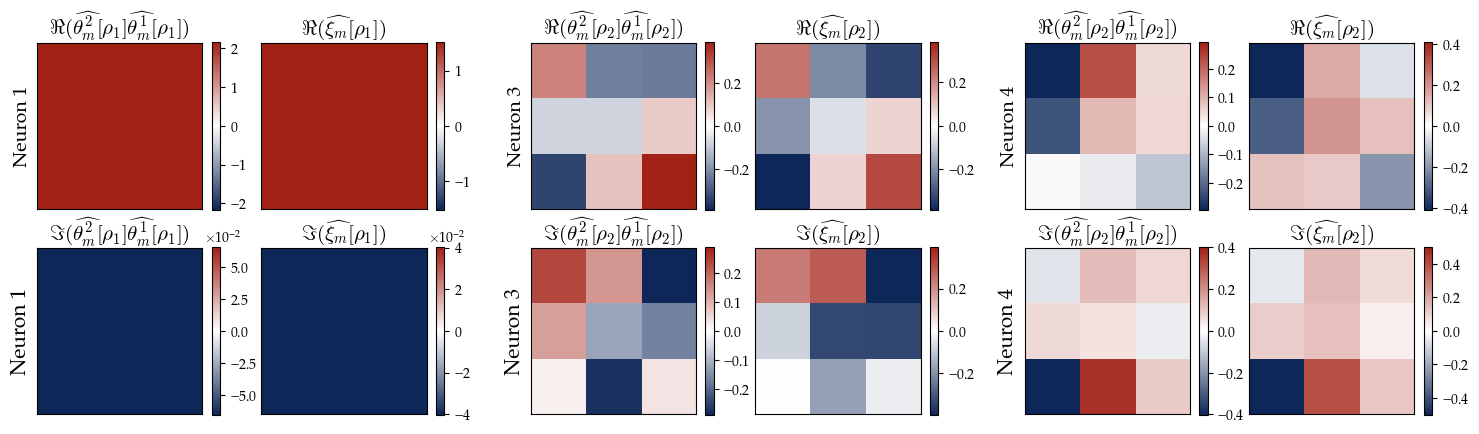


Proportionality check: W2 @ W1 ≈ c · Wout
Neuron     Irrep           Residual        Status         
------------------------------------------------------------
1          omega           0.0038          ✓ Aligned      
3          rho_3           0.4402          ✗ Misaligned   
4          rho_3           0.3397          ✗ Misaligned   


In [13]:
# Compare W2 @ W1 vs Wout for selected neurons
# 2×6 grid: Top row = Real, Bottom row = Imaginary
# Columns alternate: neuron1 product, neuron1 xi, neuron2 product, neuron2 xi, ...
# Automatically detects which irrep each neuron specializes in

from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter

# ============ USER CONFIGURATION ============
# Select neurons by their IDs (0-indexed)
selected_neuron_ids = [0,2,3]  # Just pick any 3 neurons
# ============================================

# LaTeX labels for irreps
irrep_latex = {
    'trivial': r'\rho_{\sf triv}',
    'omega': r'\rho_1',
    'rho_3': r'\rho_2',
    'rho_3_conj': r'\rho_2^\vee',
    'omega_conj': r'\rho_1^\vee',
}

def get_dominant_irrep(neuron_idx):
    """Find which irrep a neuron specializes in (highest energy)."""
    energies = energy_pos1[neuron_idx]
    dominant_idx = np.argmax(energies)
    return basis.irrep_labels[dominant_idx]

def add_colorbar_scientific(fig, im, ax):
    """Add colorbar with scientific notation (10^{-n} scale), offset text moved right."""
    cbar = fig.colorbar(im, ax=ax, fraction=0.046)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.ax.ticklabel_format(style='scientific', scilimits=(-2, 2))
    # Move the exponent label (×10^n) to the right
    cbar.ax.yaxis.get_offset_text().set_x(3.5)
    return cbar

# Detect irrep for each selected neuron
neuron_irreps = [(m, get_dominant_irrep(m)) for m in selected_neuron_ids]
print("Selected neurons and their dominant irreps:")
for m, irrep in neuron_irreps:
    d = basis.irrep_dimensions[irrep]
    print(f"  Neuron {m+1}: {irrep} (dim={d})")

# Create figure with GridSpec for custom spacing
# 8 columns: [n1_prod, n1_xi, gap, n2_prod, n2_xi, gap, n3_prod, n3_xi]
fig = plt.figure(figsize=(18, 5))
gs = GridSpec(2, 8, figure=fig,
              width_ratios=[1, 1, 0.02, 1, 1, 0.02, 1, 1],
              hspace=0.14, wspace=0.3)

# Map neuron index to actual grid columns (skipping gap columns)
col_map = [(0, 1), (3, 4), (6, 7)]  # (product_col, xi_col) for each neuron

for i, (m, irrep_label) in enumerate(neuron_irreps):
    d = basis.irrep_dimensions[irrep_label]
    rho_tex = irrep_latex.get(irrep_label, irrep_label)

    W1 = W_in_pos1_matrices[irrep_label][m]
    W2 = W_in_pos2_matrices[irrep_label][m]
    Wout = W_out_matrices[irrep_label][m]

    # W2 @ W1 (paper's convention)
    W2_W1 = W2 @ W1

    col_product, col_xi = col_map[i]

    # Top row: Real parts
    # W2@W1 Real - independent colorbar
    ax = fig.add_subplot(gs[0, col_product])
    vmax_w2w1_re = max(np.abs(W2_W1.real).max(), 1e-10)
    im = ax.imshow(W2_W1.real, cmap=blue_white_red, vmin=-vmax_w2w1_re, vmax=vmax_w2w1_re)
    ax.set_title(r'$\Re(\widehat{\theta_m^2}[' + rho_tex + r']\widehat{\theta_m^1}[' + rho_tex + r'])$', fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(f'Neuron {m+1}', fontsize=14)
    add_colorbar_scientific(fig, im, ax)

    # Wout Real - independent colorbar
    ax = fig.add_subplot(gs[0, col_xi])
    vmax_wout_re = max(np.abs(Wout.real).max(), 1e-10)
    im = ax.imshow(Wout.real, cmap=blue_white_red, vmin=-vmax_wout_re, vmax=vmax_wout_re)
    ax.set_title(r'$\Re(\widehat{\xi_m}[' + rho_tex + r'])$', fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    add_colorbar_scientific(fig, im, ax)

    # Bottom row: Imaginary parts
    # W2@W1 Imag - independent colorbar
    ax = fig.add_subplot(gs[1, col_product])
    vmax_w2w1_im = max(np.abs(W2_W1.imag).max(), 1e-10)
    im = ax.imshow(W2_W1.imag, cmap=blue_white_red, vmin=-vmax_w2w1_im, vmax=vmax_w2w1_im)
    ax.set_title(r'$\Im(\widehat{\theta_m^2}[' + rho_tex + r']\widehat{\theta_m^1}[' + rho_tex + r'])$', fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(f'Neuron {m+1}', fontsize=15)
    add_colorbar_scientific(fig, im, ax)

    # Wout Imag - independent colorbar
    ax = fig.add_subplot(gs[1, col_xi])
    vmax_wout_im = max(np.abs(Wout.imag).max(), 1e-10)
    im = ax.imshow(Wout.imag, cmap=blue_white_red, vmin=-vmax_wout_im, vmax=vmax_wout_im)
    ax.set_title(r'$\Im(\widehat{\xi_m}[' + rho_tex + r'])$', fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    add_colorbar_scientific(fig, im, ax)

plt.show()

# Summary table
print("\nProportionality check: W2 @ W1 ≈ c · Wout")
print("=" * 60)
print(f"{'Neuron':<10} {'Irrep':<15} {'Residual':<15} {'Status':<15}")
print("-" * 60)
for m, irrep_label in neuron_irreps:
    W1 = W_in_pos1_matrices[irrep_label][m]
    W2 = W_in_pos2_matrices[irrep_label][m]
    Wout = W_out_matrices[irrep_label][m]

    W2_W1 = W2 @ W1
    W2_W1_norm = W2_W1 / (np.linalg.norm(W2_W1, 'fro') + 1e-10)
    Wout_norm = Wout / (np.linalg.norm(Wout, 'fro') + 1e-10)
    residual = np.linalg.norm(W2_W1_norm - Wout_norm, 'fro')
    status = "✓ Aligned" if residual < 0.1 else "✗ Misaligned"

    print(f"{m+1:<10} {irrep_label:<15} {residual:<15.4f} {status:<15}")

In [14]:
# Check if θ̂₁, θ̂₂, ξ̂ matrices are rank-1 for ALL neurons
# A rank-1 matrix M can be written as M = u @ v^H (outer product)
# We check this by looking at singular values: σ₁ >> σ₂ ≈ ... ≈ σ_d ≈ 0
#
# Note: Singular values (from SVD) are ALWAYS real and non-negative, even for complex matrices.
#       Eigenvalues can be complex. For rank-1 check, we use singular values.

RANK1_THRESHOLD = 0.1  # σ₂/σ₁ < threshold means rank-1

# Collect statistics for all neurons
rank1_stats = {'θ̂₁': {'rank1': 0, 'total': 0, 'ratios': []},
               'θ̂₂': {'rank1': 0, 'total': 0, 'ratios': []},
               'ξ̂': {'rank1': 0, 'total': 0, 'ratios': []}}

all_neuron_data = []  # Store data for all neurons

for m in range(M):
    # Find dominant irrep for this neuron
    energies = energy_pos1[m]
    dom_idx = np.argmax(energies)
    irrep_label = basis.irrep_labels[dom_idx]
    d = basis.irrep_dimensions[irrep_label]
    
    W1 = W_in_pos1_matrices[irrep_label][m]
    W2 = W_in_pos2_matrices[irrep_label][m]
    Wout = W_out_matrices[irrep_label][m]
    
    neuron_info = {'m': m, 'irrep': irrep_label, 'd': d}
    
    for name, mat in [('θ̂₁', W1), ('θ̂₂', W2), ('ξ̂', Wout)]:
        singular_values = np.linalg.svd(mat, compute_uv=False)
        sigma1 = singular_values[0]
        sigma2 = singular_values[1] if len(singular_values) > 1 else 0
        ratio = sigma2 / sigma1 if sigma1 > 1e-10 else np.inf
        
        neuron_info[f'{name}_σ1'] = sigma1
        neuron_info[f'{name}_σ2'] = sigma2
        neuron_info[f'{name}_ratio'] = ratio
        neuron_info[f'{name}_rank1'] = ratio < RANK1_THRESHOLD
        
        # Also compute eigenvalues (can be complex)
        eigenvalues = np.linalg.eigvals(mat)
        neuron_info[f'{name}_eigs'] = eigenvalues
        
        # Only count d > 1 for statistics
        if d > 1:
            rank1_stats[name]['total'] += 1
            rank1_stats[name]['ratios'].append(ratio)
            if ratio < RANK1_THRESHOLD:
                rank1_stats[name]['rank1'] += 1
    
    all_neuron_data.append(neuron_info)

# Summary statistics
print("Rank-1 check for Fourier coefficient matrices (ALL neurons)")
print("=" * 80)
print("\nNote: We use SINGULAR VALUES (always real ≥ 0) for rank check, not eigenvalues.")
print("      Eigenvalues of complex matrices can be complex.")
print(f"\nSummary (d > 1 irreps only, threshold σ₂/σ₁ < {RANK1_THRESHOLD}):")
print("-" * 80)
print(f"{'Matrix':<10} {'Rank-1':<12} {'Total':<12} {'Percentage':<12} {'Mean σ₂/σ₁':<15} {'Max σ₂/σ₁':<15}")
print("-" * 80)
for name, stats in rank1_stats.items():
    pct = 100 * stats['rank1'] / stats['total'] if stats['total'] > 0 else 0
    mean_ratio = np.mean(stats['ratios']) if stats['ratios'] else 0
    max_ratio = np.max(stats['ratios']) if stats['ratios'] else 0
    print(f"{name:<10} {stats['rank1']:<12} {stats['total']:<12} {pct:<12.1f}% {mean_ratio:<15.6f} {max_ratio:<15.6f}")

# Count by irrep type
print("\n" + "=" * 80)
print("Breakdown by irrep type:")
print("-" * 80)

for irrep_label in basis.irrep_labels:
    d = basis.irrep_dimensions[irrep_label]
    if d == 1:
        count = sum(1 for n in all_neuron_data if n['irrep'] == irrep_label)
        print(f"{irrep_label} (d=1): {count} neurons - trivially rank-1")
    else:
        neurons_in_irrep = [n for n in all_neuron_data if n['irrep'] == irrep_label]
        count = len(neurons_in_irrep)
        if count > 0:
            rank1_theta1 = sum(1 for n in neurons_in_irrep if n['θ̂₁_rank1'])
            rank1_theta2 = sum(1 for n in neurons_in_irrep if n['θ̂₂_rank1'])
            rank1_xi = sum(1 for n in neurons_in_irrep if n['ξ̂_rank1'])
            print(f"{irrep_label} (d={d}): {count} neurons")
            print(f"    θ̂₁ rank-1: {rank1_theta1}/{count} ({100*rank1_theta1/count:.1f}%)")
            print(f"    θ̂₂ rank-1: {rank1_theta2}/{count} ({100*rank1_theta2/count:.1f}%)")
            print(f"    ξ̂  rank-1: {rank1_xi}/{count} ({100*rank1_xi/count:.1f}%)")

# Show first 10 neurons with d > 1 irreps in detail (with both singular values and eigenvalues)
print("\n" + "=" * 120)
print("Detailed view (first 10 neurons with d > 1 irreps):")
print("Showing both SINGULAR VALUES (real) and EIGENVALUES (complex)")
print("=" * 120)

count_shown = 0
for n in all_neuron_data:
    if n['d'] == 1:
        continue
    if count_shown >= 10:
        break
    
    print(f"\nNeuron {n['m']+1} ({n['irrep']}, d={n['d']}):")
    print("-" * 100)
    
    for name in ['θ̂₁', 'θ̂₂', 'ξ̂']:
        status = "✓ Rank-1" if n[f'{name}_rank1'] else "✗ Full rank"
        
        # Format singular values
        sv_str = f"σ = [{n[f'{name}_σ1']:.6f}, {n[f'{name}_σ2']:.6f}, ...]"
        
        # Format eigenvalues (complex)
        eigs = n[f'{name}_eigs']
        eig_strs = [f"{e.real:.4f}{'+' if e.imag >= 0 else ''}{e.imag:.4f}j" for e in eigs[:3]]
        eig_str = f"λ = [{', '.join(eig_strs)}]"
        
        print(f"  {name}: {status}")
        print(f"       Singular values (real): {sv_str}  (σ₂/σ₁ = {n[f'{name}_ratio']:.6f})")
        print(f"       Eigenvalues (complex):  {eig_str}")
    
    count_shown += 1

print(f"\n(Showing {count_shown} of {sum(1 for n in all_neuron_data if n['d'] > 1)} neurons with d > 1 irreps)")

Rank-1 check for Fourier coefficient matrices (ALL neurons)

Note: We use SINGULAR VALUES (always real ≥ 0) for rank check, not eigenvalues.
      Eigenvalues of complex matrices can be complex.

Summary (d > 1 irreps only, threshold σ₂/σ₁ < 0.1):
--------------------------------------------------------------------------------
Matrix     Rank-1       Total        Percentage   Mean σ₂/σ₁      Max σ₂/σ₁      
--------------------------------------------------------------------------------
θ̂₁        79           455          17.4        % 0.243263        0.507200       
θ̂₂        77           455          16.9        % 0.240781        0.524293       
ξ̂         68           455          14.9        % 0.242868        0.563128       

Breakdown by irrep type:
--------------------------------------------------------------------------------
trivial (d=1): 0 neurons - trivially rank-1
omega (d=1): 34 neurons - trivially rank-1
rho_3 (d=3): 455 neurons
    θ̂₁ rank-1: 79/455 (17.4%)
    θ̂₂ r